In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Model Training

## MobileNetV2

In [ ]:
!cp -r "/content/drive/MyDrive/Environmental_ai_healthcare_system/dataset/split_v2" /content/

In [ ]:
import os

print(os.listdir("/content"))
print(os.listdir("/content/split_v2"))
print(os.listdir("/content/split_v2/train"))

['.config', 'split_v2', 'drive', 'sample_data']
['test', 'train', 'val']
['hygienic_environment', 'stagnant_water', 'garbage_dirty', 'air_pollution']


In [ ]:
BASE_PATH = "/content/split_v2"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH = os.path.join(BASE_PATH, "test")
VAL_PATH = os.path.join(BASE_PATH, "val")

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import MobileNetV2

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 9352 files belonging to 4 classes.
Found 1169 files belonging to 4 classes.
Found 1171 files belonging to 4 classes.
Classes: ['air_pollution', 'garbage_dirty', 'hygienic_environment', 'stagnant_water']


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
print("Collecting training labels for class weight calculation...")
train_labels = []

for _, labels in train_ds.unbatch():
    train_labels.append(labels.numpy())

train_labels = np.array(train_labels)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights calculated:")
for i, weight in class_weights_dict.items():
    print(f"  Class {class_names[i]} ({i}): {weight:.2f}")

Class weights calculated:
  Class air_pollution (0): 0.72
  Class garbage_dirty (1): 4.87
  Class hygienic_environment (2): 0.58
  Class stagnant_water (3): 1.46


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
base_model_mob = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model_mob.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model_mob(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
outputs = Dense(num_classes, activation="softmax")(x)

model_mob = Model(inputs, outputs)

model_mob.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mob.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Training model with data augmentation...")
history_mob = model_mob.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Training model with data augmentation...
Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.5923 - loss: 0.8512 - val_accuracy: 0.8007 - val_loss: 0.4601
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.8312 - loss: 0.3504 - val_accuracy: 0.8631 - val_loss: 0.3556
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.8612 - loss: 0.2853 - val_accuracy: 0.8802 - val_loss: 0.3119
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8816 - loss: 0.2387 - val_accuracy: 0.8914 - val_loss: 0.2874
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.8994 - loss: 0.2147 - val_accuracy: 0.8931 - val_loss: 0.2783
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - accuracy: 0.9142 - loss: 0.1953 - val_accuracy: 0.9008 - val_loss: 0.2557
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.9166 - loss: 0.1902 - val_accuracy: 0.9050 - val_loss: 0.2435
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/

In [ ]:
# Fine-tuning
base_model_mob.trainable = True

for layer in base_model_mob.layers[:-60]:
    layer.trainable = False

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning model with data augmentation...")
history_finetune_mob = model_mob.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Fine-tuning model with data augmentation...
Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 50s 120ms/step - accuracy: 0.7970 - loss: 0.5214 - val_accuracy: 0.9059 - val_loss: 0.2609
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 116ms/step - accuracy: 0.8770 - loss: 0.2551 - val_accuracy: 0.8708 - val_loss: 0.3337
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 33s 113ms/step - accuracy: 0.9081 - loss: 0.2037 - val_accuracy: 0.8845 - val_loss: 0.3188
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.9183 - loss: 0.1776 - val_accuracy: 0.8888 - val_loss: 0.2927
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 115ms/step - accuracy: 0.9360 - loss: 0.1443 - val_accuracy: 0.8956 - val_loss: 0.2749
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - accuracy: 0.9495 - loss: 0.1170 - val_accuracy: 0.9179 - val_loss: 0.2120
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 34s 115ms/step - accuracy: 0.9539 - loss: 0.1111 - val_accuracy: 0.9162 - val_loss: 0.2099
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━

Found 1171 files belonging to 4 classes.
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step


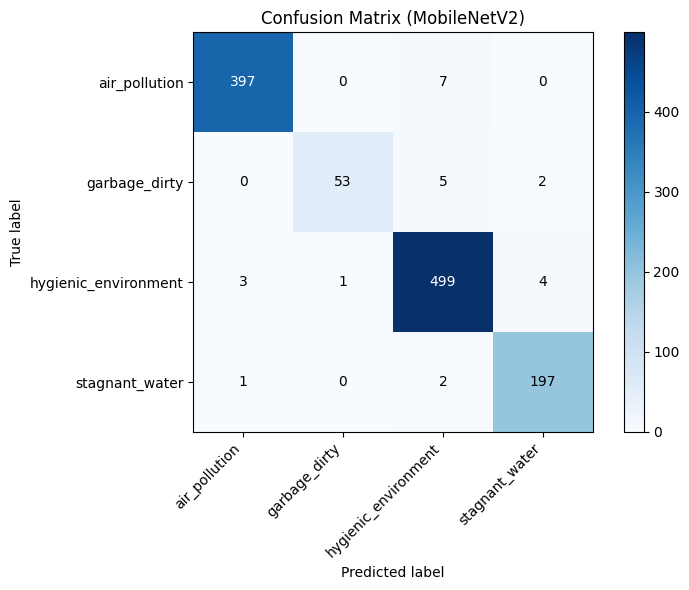

In [ ]:
test_ds_eval = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_ds_eval = test_ds_eval.map(lambda x, y: (normalization_layer(x), y))
test_ds_eval = test_ds_eval.prefetch(buffer_size=AUTOTUNE)

y_pred_probs_mob = model_mob.predict(test_ds_eval)
y_pred_mob = np.argmax(y_pred_probs_mob, axis=1)

y_true_mob = np.concatenate([y for x, y in test_ds_eval], axis=0)

cm_mob = confusion_matrix(y_true_mob, y_pred_mob)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm_mob, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (MobileNetV2)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

fmt = 'd'
thresh = cm_mob.max() / 2.
for i in range(cm_mob.shape[0]):
    for j in range(cm_mob.shape[1]):
        plt.text(j, i, format(cm_mob[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm_mob[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# Classification Report
print("Classification Report (MobileNetV2):")
print(classification_report(y_true_mob, y_pred_mob, target_names=class_names))

Classification Report (MobileNetV2):
                      precision    recall  f1-score   support

       air_pollution       0.99      0.98      0.99       404
       garbage_dirty       0.98      0.88      0.93        60
hygienic_environment       0.97      0.98      0.98       507
      stagnant_water       0.97      0.98      0.98       200

            accuracy                           0.98      1171
           macro avg       0.98      0.96      0.97      1171
        weighted avg       0.98      0.98      0.98      1171



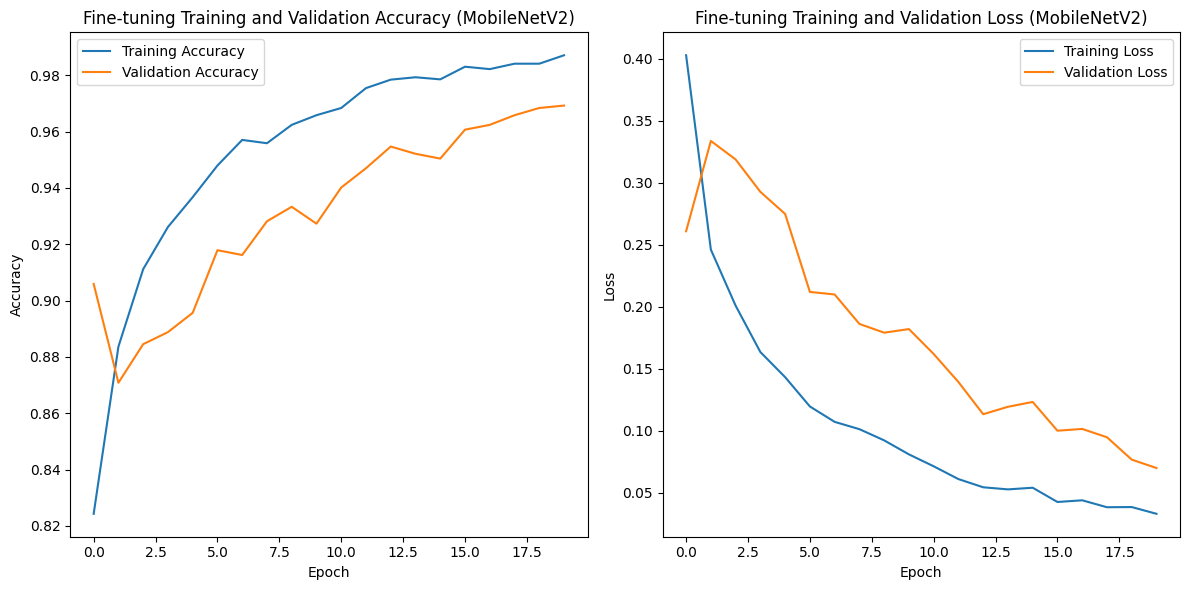

In [ ]:
# Plotting training and validation accuracy for fine-tuning
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_finetune_mob.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune_mob.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-tuning Training and Validation Accuracy (MobileNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss for fine-tuning
plt.subplot(1, 2, 2)
plt.plot(history_finetune_mob.history['loss'], label='Training Loss')
plt.plot(history_finetune_mob.history['val_loss'], label='Validation Loss')
plt.title('Fine-tuning Training and Validation Loss (MobileNetV2)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_mob.save("/content/drive/MyDrive/Environmental_ai_healthcare_system/mobilenet_model.keras")

## EfficientNetB0

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_eff.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model_eff(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_eff = tf.keras.Model(inputs, outputs)

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.5935 - loss: 0.8978 - val_accuracy: 0.8512 - val_loss: 0.4077
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.8582 - loss: 0.3158 - val_accuracy: 0.9042 - val_loss: 0.2746
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.8972 - loss: 0.2283 - val_accuracy: 0.9093 - val_loss: 0.2291
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.9237 - loss: 0.1860 - val_accuracy: 0.9316 - val_loss: 0.1898
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 91ms/step - accuracy: 0.9340 - loss: 0.1527 - val_accuracy: 0.9333 - val_loss: 0.1722
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.9377 - loss: 0.1425 - val_accuracy: 0.9453 - val_loss: 0.1554
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.9412 - loss: 0.1300 - val_accuracy: 0.9478 - val_loss: 0.1437
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.9481 - loss: 0.1191 -

In [ ]:
#Fine Tuning
base_model_eff.trainable = True

for layer in base_model_eff.layers[:-60]:
    layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_eff_finetune = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step - accuracy: 0.8428 - loss: 0.3898 - val_accuracy: 0.9376 - val_loss: 0.2027
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - accuracy: 0.9031 - loss: 0.2365 - val_accuracy: 0.9427 - val_loss: 0.1761
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.9211 - loss: 0.1868 - val_accuracy: 0.9478 - val_loss: 0.1497
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - accuracy: 0.9335 - loss: 0.1541 - val_accuracy: 0.9589 - val_loss: 0.1319
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - accuracy: 0.9479 - loss: 0.1266 - val_accuracy: 0.9624 - val_loss: 0.1161
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.9496 - loss: 0.1154 - val_accuracy: 0.9632 - val_loss: 0.1026
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - accuracy: 0.9533 - loss: 0.1087 - val_accuracy: 0.9692 - val_loss: 0.0968
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - accuracy: 0.9576 - loss: 0

Found 1171 files belonging to 4 classes.
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step


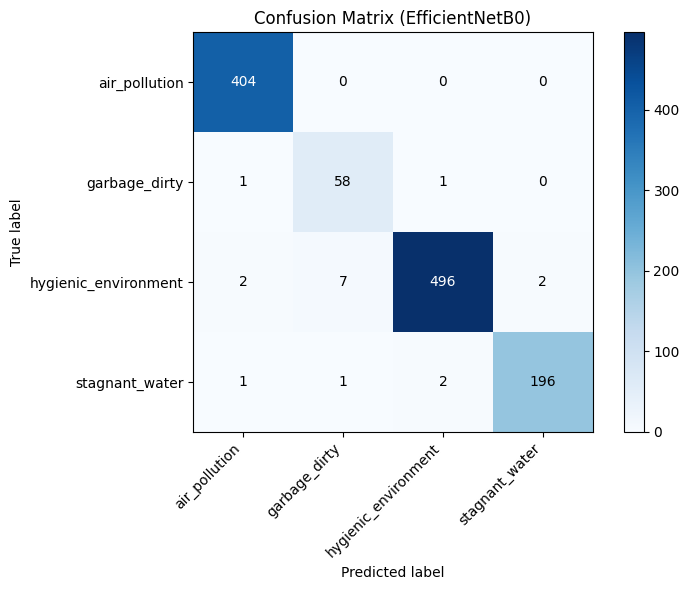

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

test_ds_eval = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_eval = test_ds_eval.map(
    lambda x, y: (preprocess_input(x), y)
).prefetch(AUTOTUNE)

# Predictions
y_pred_probs_eff = model_eff.predict(test_ds_eval)
y_pred_eff = np.argmax(y_pred_probs_eff, axis=1)

# True labels
y_true_eff = np.concatenate(
    [y.numpy() for _, y in test_ds_eval],
    axis=0
)

# Confusion Matrix
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(cm_eff, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (EfficientNetB0)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

fmt = 'd'
thresh = cm_eff.max() / 2.
for i in range(cm_eff.shape[0]):
    for j in range(cm_eff.shape[1]):
        plt.text(j, i, format(cm_eff[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm_eff[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# Classification Report
print("Classification Report (EfficientNetB0):")
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))

Classification Report (EfficientNetB0):
                      precision    recall  f1-score   support

       air_pollution       0.99      1.00      1.00       404
       garbage_dirty       0.88      0.97      0.92        60
hygienic_environment       0.99      0.98      0.99       507
      stagnant_water       0.99      0.98      0.98       200

            accuracy                           0.99      1171
           macro avg       0.96      0.98      0.97      1171
        weighted avg       0.99      0.99      0.99      1171



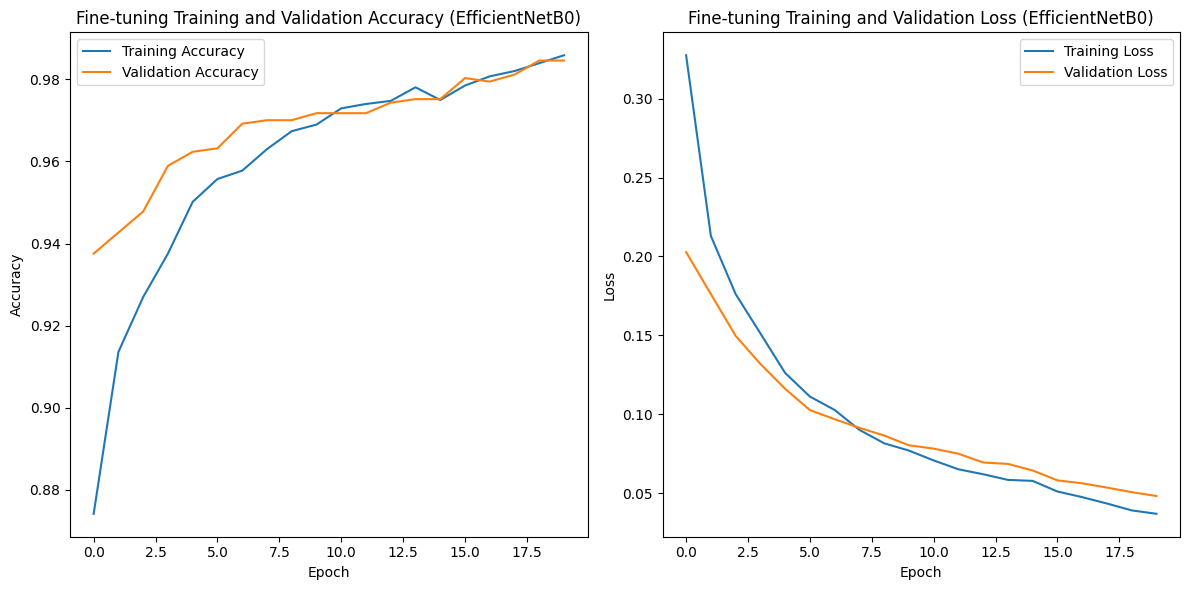

In [ ]:
# Plotting training and validation accuracy for EfficientNet fine-tuning
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history_eff_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_eff_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-tuning Training and Validation Accuracy (EfficientNetB0)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss for EfficientNet fine-tuning
plt.subplot(1, 2, 2)
plt.plot(history_eff_finetune.history['loss'], label='Training Loss')
plt.plot(history_eff_finetune.history['val_loss'], label='Validation Loss')
plt.title('Fine-tuning Training and Validation Loss (EfficientNetB0)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_eff.save("/content/drive/MyDrive/Environmental_ai_healthcare_system/efficientnet_model.keras")

### Final Model: **EfficientNetB0**

Chosen over MobileNetV2 due to improved minority class recall (97% vs 88% for garbage_dirty), ensuring better detection of critical environmental risk cases.

# Demo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model_eff = load_model("/content/drive/MyDrive/Environmental_ai_healthcare_system/efficientnet_model.keras")

Saving 8-Major-Sources-Of-Air-Pollution-1024x639.webp to 8-Major-Sources-Of-Air-Pollution-1024x639.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


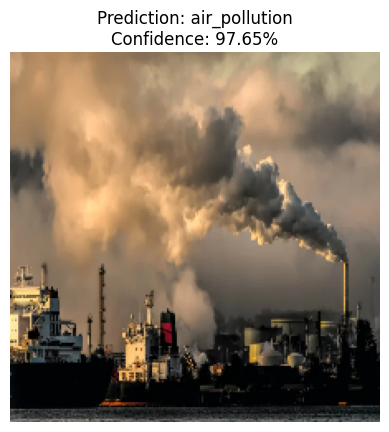

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

# Upload file
uploaded = files.upload()

# Get filename
img_path = list(uploaded.keys())[0]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

class_names = ['air_pollution', 'garbage_dirty', 'hygienic_environment', 'stagnant_water']

# Predict
predictions = model_eff.predict(img_array)
predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

# Display image
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.show()